## Business Objective
the objective of this project is to analyze historical customer data from a subscription-based company to identify factors associated with customer churn and to build a predictive model that estimates the likelihood of churn.

The analysis focuses on understanding customer behavior patterns and translating them into actionable business insights.

In [8]:
# Import core libraries
# Numberical and data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
	accuracy_score,
	precision_score,
	recall_score,
	roc_auc_score
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# General settings
import warnings
warnings.filterwarnings("ignore")

# Visualization settings
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

In [13]:
# Load the CSV
data_path = "../data/telco_churn.csv"
df = pd.read_csv(data_path)

# Basic structure checks
print("Dataset shape:", df.shape)
display(df.head())

# Schema and missing values overview
print("Schema and missing values overview")
df.info()

Dataset shape: (5043, 22)


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000381469727,False
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.5,False
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.1500015258789,True
3,3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.64999389648438,True


Schema and missing values overview
<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   str    
 2   gender            5043 non-null   str    
 3   SeniorCitizen     5043 non-null   str    
 4   Partner           5043 non-null   str    
 5   Dependents        5043 non-null   str    
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   str    
 8   MultipleLines     4774 non-null   str    
 9   InternetService   5043 non-null   str    
 10  OnlineSecurity    4392 non-null   str    
 11  OnlineBackup      4392 non-null   str    
 12  DeviceProtection  4392 non-null   str    
 13  TechSupport       4392 non-null   str    
 14  StreamingTV       4392 non-null   str    
 15  StreamingMovies   4392 non-null   str    
 16  Contract          

In [10]:
# Check target variable distribution
df["Churn"].value_counts(normalize = True)

Churn
False    0.440103
No       0.294923
True     0.154701
Yes      0.110274
Name: proportion, dtype: float64

In [ ]:
# Display basic structure
# Dimensions of the dataset
print(f"Number of rows and columns: {df.shape}")

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# First few rows
print("\nFirst few rows:")
display(df.head())

# Data types and non-null counts
print("\nData types and non-null counts:")
df.info()

# Statistical summary for numerical columns
print("\nStatistical summary for numerical columns:")
df.describe()

Number of rows and columns: (5043, 22)

Column names:
['Unnamed: 0', 'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,7590-VHVEG,Female,False,True,False,1,False,NaN,DSL,...,False,False,False,False,Month-to-month,True,Electronic check,29.850000,29.850000381469727,False
1,1,5575-GNVDE,Male,False,False,False,34,True,False,DSL,...,True,False,False,False,One year,False,Mailed check,56.950001,1889.5,False
2,2,3668-QPYBK,Male,False,False,False,2,True,False,DSL,...,False,False,False,False,Month-to-month,True,Mailed check,53.849998,108.1500015258789,True
3,3,7795-CFOCW,Male,False,False,False,45,False,NaN,DSL,...,True,True,False,False,One year,False,Bank transfer (automatic),42.299999,1840.75,False
4,4,9237-HQITU,Female,False,False,False,2,True,False,Fiber optic,...,False,False,False,False,Month-to-month,True,Electronic check,70.699997,151.64999389648438,True


<class 'pandas.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5043 non-null   int64  
 1   customerID        5043 non-null   str    
 2   gender            5043 non-null   str    
 3   SeniorCitizen     5043 non-null   str    
 4   Partner           5043 non-null   str    
 5   Dependents        5043 non-null   str    
 6   tenure            5043 non-null   int64  
 7   PhoneService      5043 non-null   str    
 8   MultipleLines     4774 non-null   str    
 9   InternetService   5043 non-null   str    
 10  OnlineSecurity    4392 non-null   str    
 11  OnlineBackup      4392 non-null   str    
 12  DeviceProtection  4392 non-null   str    
 13  TechSupport       4392 non-null   str    
 14  StreamingTV       4392 non-null   str    
 15  StreamingMovies   4392 non-null   str    
 16  Contract          5043 non-null   str    
 17  Paperl

,Unnamed: 0,tenure,MonthlyCharges
count,5043.000000,5043.000000,5043.000000
mean,1305.651993,32.576641,65.090214
std,801.484415,24.529807,30.068133
min,0.000000,0.000000,18.400000
25%,630.000000,9.000000,35.775000
50%,1260.000000,29.000000,70.550003
75%,1890.500000,56.000000,90.050003
max,2999.000000,72.000000,118.650002


Churn counts: Churn
False    2219
No       1487
True      780
Yes       556
Name: count, dtype: int64
Churn distribution: Churn
False    44.01
No       29.49
True     15.47
Yes      11.03
Name: proportion, dtype: float64%


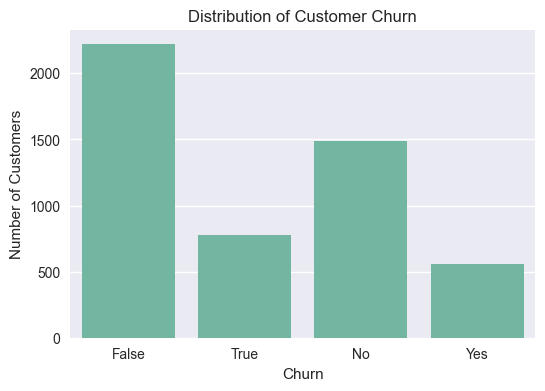

In [12]:
# Check churn distribution
# - Absolute and relative distribution of the target variable (churn)
churn_counts = df["Churn"].value_counts()
churn_ratio = df["Churn"].value_counts(normalize = True)

print(f"Churn counts: {churn_counts}")
print(f"Churn distribution: {(churn_ratio * 100).round(2)}%")

# - Visualize churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x = "Churn", data = df)
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

# - Note any imbalance in markdown


## Data Understanding
- Number of records:
- Number of features:
- Target variable distribution:
- Notable data issues (if any):

In [15]:
df["Churn"] = df["Churn"].replace({"True": "Yes", "False": "No"})
df["Churn"].value_counts()

Churn
No     3706
Yes    1336
Name: count, dtype: int64